1. Data understanding and Loading 

**Importing csv and displaying 5 records**

In [298]:
import pandas as pd

df=pd.read_csv('users_with_missing_values.csv')
df.head()
# df.shape

,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35.0,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30.0,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37.0,Other,NaN,2022-02-02
3,U0004,Aarav Gupta,44.0,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30.0,NaN,Chennai,2024-01-04


In [299]:
df['new_gender']=df['gender'].copy()

Identifying datatypes

In [300]:
df.dtypes

user_id               object
name                  object
age                  float64
gender                object
city                  object
registration_date     object
new_gender            object
dtype: object

Converting date column to date datatype

In [301]:
df['registration_date']=pd.to_datetime(df['registration_date'], errors='coerce')
df.dtypes

user_id                      object
name                         object
age                         float64
gender                       object
city                         object
registration_date    datetime64[ns]
new_gender                   object
dtype: object

Identifying missing values

In [302]:
df.isnull().sum()

user_id               0
name                  0
age                  20
gender               20
city                 20
registration_date     0
new_gender           20
dtype: int64

**Importing json and displaying 5 records**

In [303]:
import json
import pandas as pd

with open('sales.json', 'r') as file:
    data = json.load(file)

print(pd.DataFrame(data).head())

  transaction_id user_id product_id  amount payment_type        date
0        T000001   U0024       P015   67.67       Wallet  2023-02-12
1        T000002   U0196       P044   76.44          UPI  2023-03-24
2        T000003   U0196       P049  104.57   Debit Card  2025-08-21
3        T000004   U0133       P042  102.75  Net Banking  2024-07-23
4        T000005   U0047       P038   23.89  Net Banking  2025-10-04


converting json to csv

In [304]:
import json
import csv

input_file = 'sales.json'
output_file = 'sales_csv.csv'

with open(input_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

if not isinstance(data, list):
    raise ValueError('JSON file must contain a list of objects')

headers = data[0].keys()
with open(output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=headers)
    writer.writeheader()
    writer.writerows(data)

Identifying datatypes

In [305]:
df_sales_csv=pd.read_csv('sales_with_missing_values.csv')
print(df_sales_csv.dtypes)

transaction_id     object
user_id            object
product_id         object
amount            float64
payment_type       object
date               object
dtype: object


Converting date column to date datatype

In [306]:
df_sales_csv['date']=pd.to_datetime(df_sales_csv['date'], errors='coerce')
print(df_sales_csv.dtypes)

transaction_id            object
user_id                   object
product_id                object
amount                   float64
payment_type              object
date              datetime64[ns]
dtype: object


In [307]:
df_sales_csv.head()

,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04


Identifying missing values

In [308]:
df_sales_csv.isnull().sum()

transaction_id      0
user_id             0
product_id          0
amount            100
payment_type      100
date                0
dtype: int64

1. Data cleaning

**Handling missing numerical data using SimpleImputer (median strategy).**

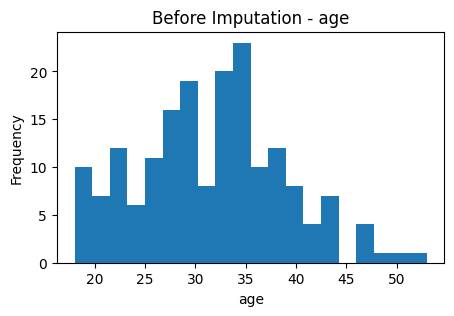

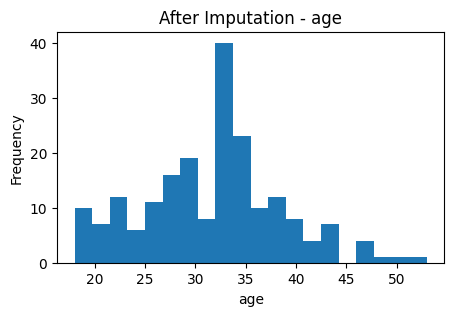

In [309]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

plt.figure(figsize=(5,3))
plt.hist(df['age'], bins=20)
plt.title(f"Before Imputation - {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

imputer = SimpleImputer(strategy='median')
df[['age']] = imputer.fit_transform(df[['age']])

plt.figure(figsize=(5,3))
plt.hist(df['age'], bins=20)
plt.title(f"After Imputation - {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

Frequency of age between 34-36 is highest and 44-46 is lowest.  
The missing values will be filled with the median value 32, so the frequency of age - 32 will be highest.

**Handling missing categorical data using most frequent imputation.**

Before Imputation


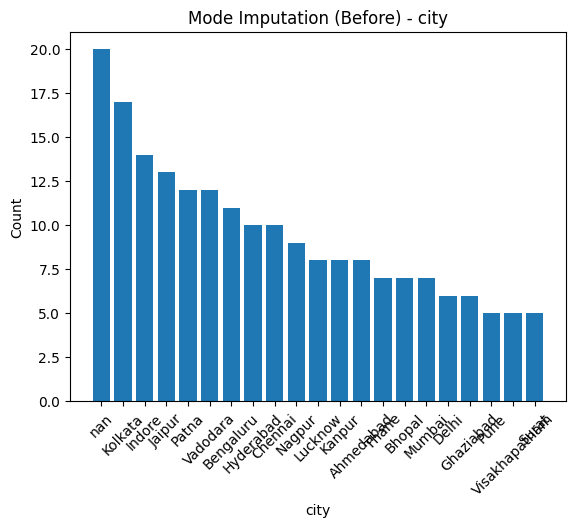

After Imputation


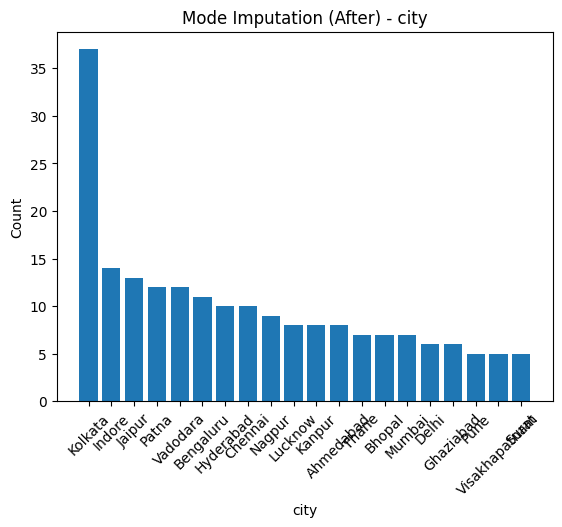

In [310]:
before_counts = df['city'].value_counts(dropna=False)
print('Before Imputation')
plt.figure()
plt.bar(before_counts.index.astype(str), before_counts.values)
plt.title(f"Mode Imputation (Before) - city")
plt.xlabel("city")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

imputer = SimpleImputer(strategy='most_frequent')
df[['city']] = imputer.fit_transform(df[['city']])

after_counts = df['city'].value_counts(dropna=False)
print('After Imputation')
plt.figure()
plt.bar(after_counts.index.astype(str), after_counts.values)
plt.title(f"Mode Imputation (After) - city")
plt.xlabel("city")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The count of kolkata is highest and surat is lowest so missing values will be filled with kolkata.

**KNN Imputer in amount column in json file(optional enhancement)**

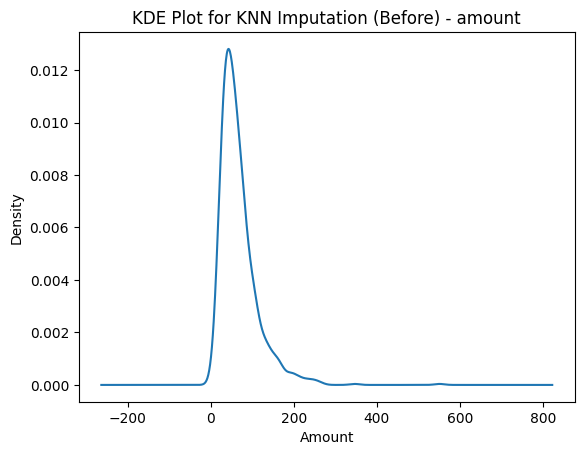

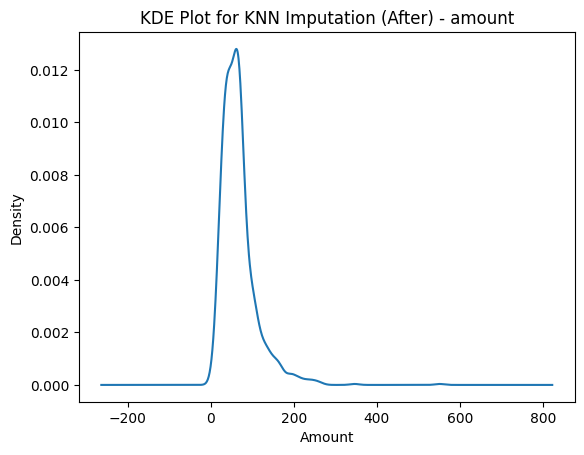

Number of missing values after imputation: 0


In [311]:
from sklearn.impute import KNNImputer

plt.figure()
df_sales_csv['amount'].plot(kind='kde')
plt.title("KDE Plot for KNN Imputation (Before) - amount")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

imputer = KNNImputer(n_neighbors=5)
df_sales_csv[['amount']] = imputer.fit_transform(df_sales_csv[['amount']])

plt.figure()
df_sales_csv['amount'].plot(kind='kde')
plt.title("KDE Plot for KNN Imputation (After) - amount")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()
print("Number of missing values after imputation:", df_sales_csv['amount'].isna().sum())

The maximum density of age is between 0 to 100 ,this suggests most transactions are for smaller amounts.  
The KDE curve shows a skewed distribution of the amount values.  
Most values are concentrated on the lower end (left side of the curve).
The kde plot Density Curve is more Smooth and continuous after imputation. 
There's a long tail extending towards higher values 

3.Outlier Handling

**Detect and remove outliers using Z-score and IQR method.**

Original Shape: (200, 7)


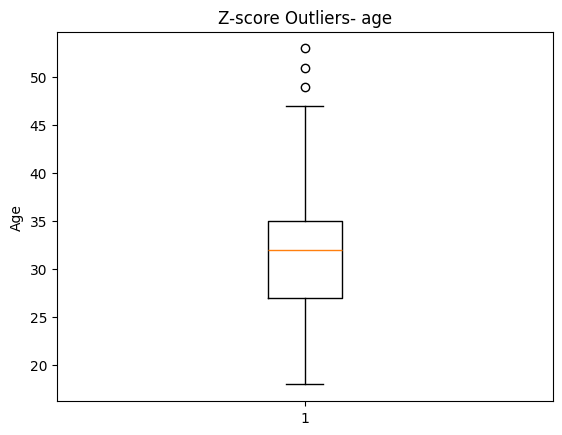

Shape After Z-Score Removal: (199, 7)


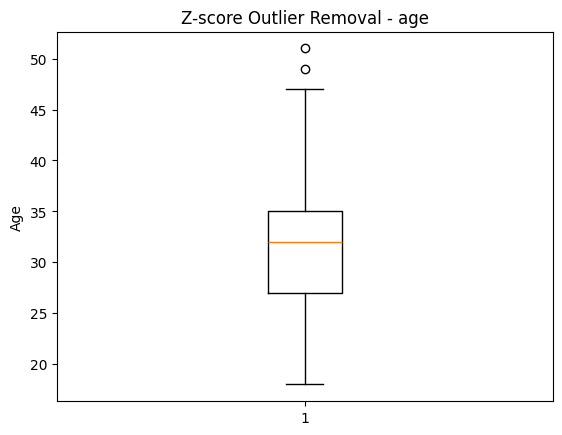

In [312]:
# using z-score in json file

import numpy as np
from scipy import stats

print('Original Shape:', df.shape)
plt.figure()
plt.boxplot(df['age'].dropna())
plt.title('Z-score Outliers- age')
plt.ylabel('Age')
plt.show()

z_scores = np.abs(stats.zscore(df['age']))
df_z = df[(z_scores < 3) & (z_scores > -3)]

print('Shape After Z-Score Removal:', df_z.shape)
plt.figure()
plt.boxplot(df_z['age'])
plt.title('Z-score Outlier Removal - age')
plt.ylabel('Age')
plt.show()

Before Z-score the outliers were above the 45 and below 55 number of age.  
No rows were removed.  
Z-score didn't detect any extreme outliers in the age column.  
After Z-Score Removal the outliers shifted below 55 age.

Original Shape: (1000, 6)


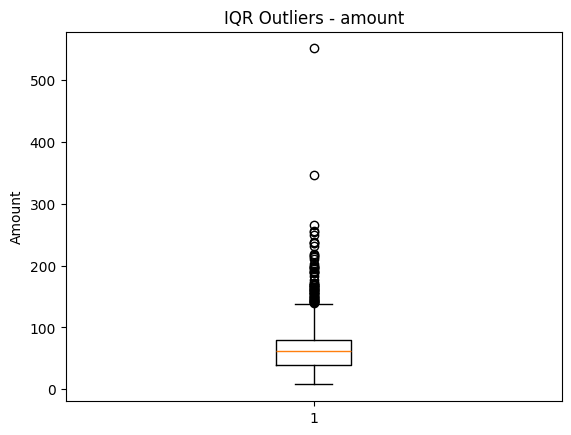

Shape After IQR Removal: (937, 6)


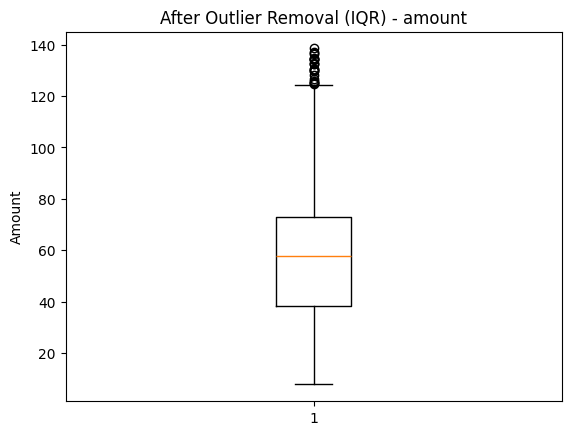

In [313]:
# IQR method
Q1 = df_sales_csv['amount'].quantile(0.25)
Q3 = df_sales_csv['amount'].quantile(0.75)
IQR = Q3 - Q1

print('Original Shape:', df_sales_csv.shape)
plt.figure()
plt.boxplot(df_sales_csv['amount'].dropna())
plt.title('IQR Outliers - amount')
plt.ylabel('Amount')
plt.show()

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_iqr = df_sales_csv[(df_sales_csv['amount'] >= lower_bound) & (df_sales_csv['amount'] <= upper_bound)]
print("Shape After IQR Removal:", df_iqr.shape)

plt.figure()
plt.boxplot(df_iqr['amount'].dropna())
plt.title("After Outlier Removal (IQR) - amount")
plt.ylabel("Amount")
plt.show()

Outliers:-  
Before: Visible as points beyond whiskers.  
After: Removed completely  

Data Spread:-  
Before: Larger range due to outliers  
After: Reduced, more concentrated  

Distribution shape: More uniform and less affected by extreme values.  
High-value outliers (extreme amounts) were filtered out.

**Compare both techniques and decide which is more suitable for this dataset.**

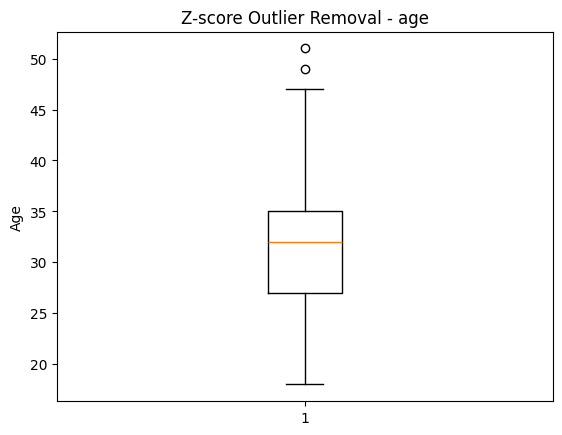

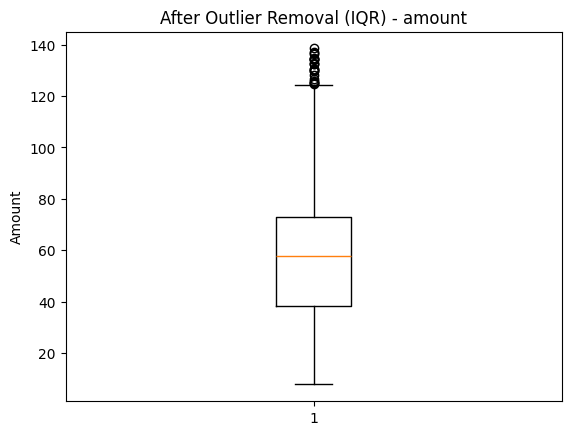

In [314]:
plt.figure()
plt.boxplot(df_z['age'])
plt.title('Z-score Outlier Removal - age')
plt.ylabel('Age')
plt.show()

plt.figure()
plt.boxplot(df_iqr['amount'].dropna())
plt.title("After Outlier Removal (IQR) - amount")
plt.ylabel("Amount")
plt.show()

Outliers Detected:-  
Z-score: Very few (extreme only).  
IQR: More sensitive.  

Rows Removed:-
Z-score: Minimal.  
IQR: More aggressive.  

Best For:-  
Z-score: Extreme outliers.  
IQR: Real-world data.  

IQR Method is more suitable because:  
- Removes actual outliers
- Not sensitive to extremes
- Distribution-independent.

**Apply Winsorization for columns where removal isn't feasible.**

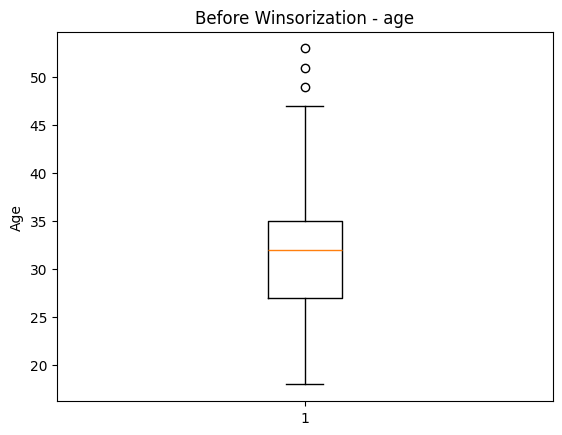

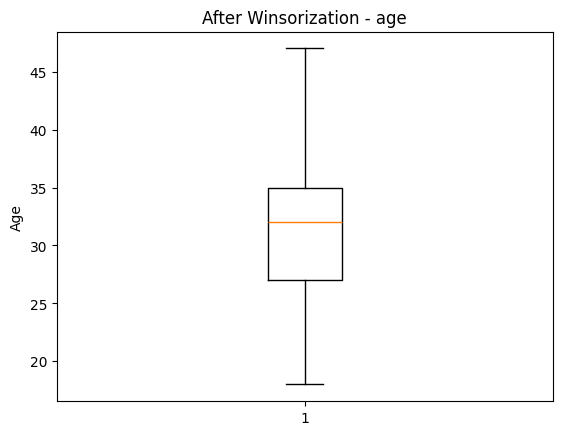

Original Min: 18.0
Original Max: 53.0
Winsorized Min: 18.0
Winsorized Max: 47.0


In [315]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure()
plt.boxplot(df['age'])
plt.title("Before Winsorization - age")
plt.ylabel("Age")
plt.show()

df_winsor = df.copy()
df_winsor['age'] = df_winsor['age'].clip(lower=lower_bound, upper=upper_bound)

plt.figure()
plt.boxplot(df_winsor['age'])
plt.title("After Winsorization - age")
plt.ylabel("Age")
plt.show()

print("Original Min:", df['age'].min())
print("Original Max:", df['age'].max())
print("Winsorized Min:", df_winsor['age'].min())
print("Winsorized Max:", df_winsor['age'].max())

Before Winsorization:  
- Outliers are above 50 age.  
- Box representing the middle 50% of data (Q1 to Q3). 
- outliers range 47 to 53.

After Winsorization:
- No outlier points  
- Box shape remains similar to before.  
- Outliers removed.

4. Data Transformation

**Converting date columns into separate day, month, year features**
##### Converting to day

In [316]:
pd.DataFrame({'registration_date': df['registration_date'], 'day_of_week': df['registration_date'].dt.day_name()}).head()

,registration_date,day_of_week
0,2022-09-08,Thursday
1,2023-11-24,Friday
2,2022-02-02,Wednesday
3,2023-06-02,Friday
4,2024-01-04,Thursday


In [317]:
df['day'] = pd.DataFrame({'registration_date': df['registration_date'], 'day_of_week': df['registration_date'].dt.day_name()})['day_of_week']

##### Converting to month

In [318]:
pd.DataFrame({'registration_date': df['registration_date'], 'month': df['registration_date'].dt.month_name()}).head()

,registration_date,month
0,2022-09-08,September
1,2023-11-24,November
2,2022-02-02,February
3,2023-06-02,June
4,2024-01-04,January


In [319]:
df['month']=df['registration_date'].dt.month_name()

##### Converting to year

In [320]:
pd.DataFrame({'registration_date': df['registration_date'], 'year': df['registration_date'].dt.year}).head()

,registration_date,year
0,2022-09-08,2022
1,2023-11-24,2023
2,2022-02-02,2022
3,2023-06-02,2023
4,2024-01-04,2024


In [321]:
df['year']=df['registration_date'].dt.year

One hot encoding in city

In [322]:
df = pd.get_dummies(df, columns=['city'], drop_first=False)
print(df.head())

  user_id           name   age gender registration_date new_gender        day  \
0   U0001  Vihaan Sharma  35.0  Other        2022-09-08      Other   Thursday   
1   U0002      Sai Reddy  30.0  Other        2023-11-24      Other     Friday   
2   U0003   Aarohi Gupta  37.0  Other        2022-02-02      Other  Wednesday   
3   U0004    Aarav Gupta  44.0   Male        2023-06-02       Male     Friday   
4   U0005    Sara Sharma  30.0    NaN        2024-01-04        NaN   Thursday   

       month  year  city_Ahmedabad  ...  city_Kolkata  city_Lucknow  \
0  September  2022           False  ...         False         False   
1   November  2023           False  ...         False         False   
2   February  2022           False  ...          True         False   
3       June  2023           False  ...          True         False   
4    January  2024           False  ...         False         False   

   city_Mumbai  city_Nagpur  city_Patna  city_Pune  city_Surat  city_Thane  \
0       

Label encoding in gender

In [323]:
print(f'Before:\n\n {df['gender'].head()}')

import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
print('\nAfter:')
df['gender'].head()

Before:

 0    Other
1    Other
2    Other
3     Male
4      NaN
Name: gender, dtype: object

After:


0    2
1    2
2    2
3    1
4    3
Name: gender, dtype: int32

After encoding: 
 
Other- 2  
Male- 1  
Nan- 3  
Female- 0

**Applying binning in age column**

After binning:

 0    (32.0, 39.0]
1    (25.0, 32.0]
2    (32.0, 39.0]
3    (39.0, 46.0]
4    (25.0, 32.0]
Name: age, dtype: category
Categories (5, interval[float64, right]): [(17.965, 25.0] < (25.0, 32.0] < (32.0, 39.0] < (39.0, 46.0] < (46.0, 53.0]]


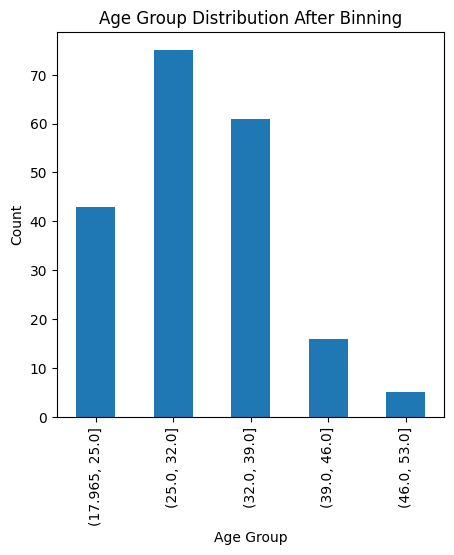

In [324]:
df['age']=pd.cut(df['age'], bins=5)
print('After binning:\n\n', df['age'].head())

plt.figure(figsize=(5,5))
df['age'].value_counts().sort_index().plot(kind='bar')
plt.title("Age Group Distribution After Binning")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

Each bins was equally divided with 7 number of age groups after binning, the highest number of people lies between the age 32 - 39 and lowest number of people lies between the age 46 - 53.

**Log transformation in json file and amount column**

Original Skewness: 2.924898055373841


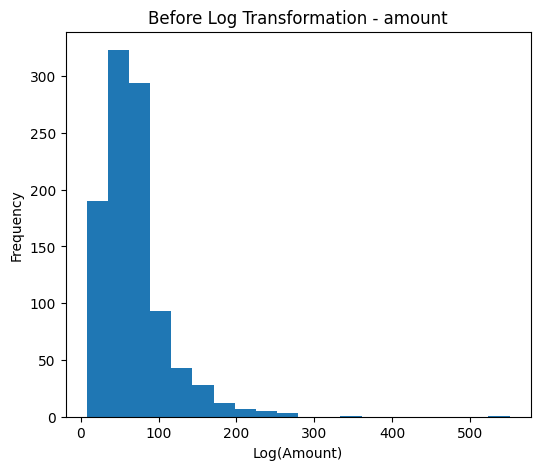

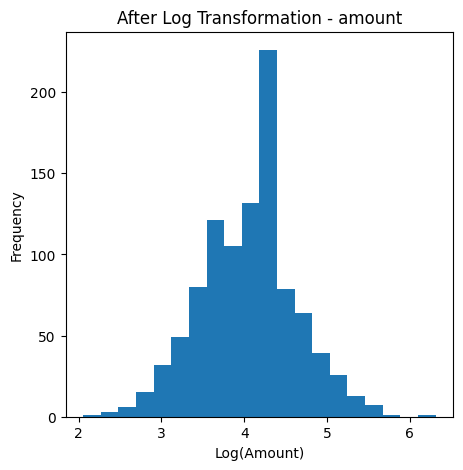

Skewness After Log: -0.022034574831243187


In [325]:
import matplotlib.pyplot as plt
import numpy as np

print("Original Skewness:", df_sales_csv['amount'].skew())

plt.figure(figsize=(6,5))
plt.hist(df_sales_csv['amount'], bins=20)
plt.title("Before Log Transformation - amount")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

df_sales_csv['amount_log'] = np.log(df_sales_csv['amount'])

plt.figure(figsize=(5,5))
plt.hist(df_sales_csv['amount_log'], bins=20)
plt.title("After Log Transformation - amount")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

print("Skewness After Log:", df_sales_csv['amount_log'].skew())

##### The amount column was positively skewed which was normally distributed using Log Transformation.  The values in amount column were multiplied with log and reduced from 0 - 600 to range 2 - 7. Skewness was reduced from 2.65 to 0.03

**Square root transformation in json file and amount column**

Skewness Before Square Root: 2.924898055373841


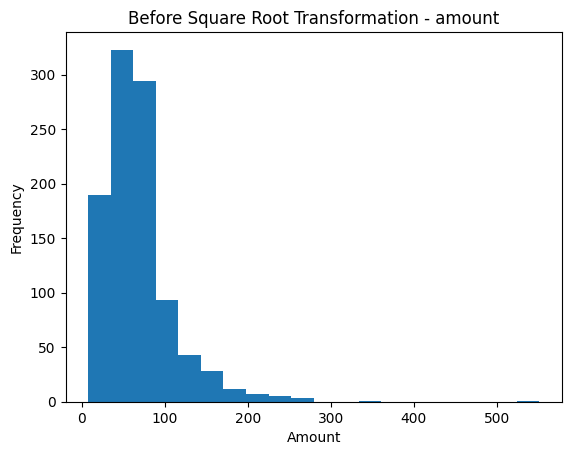

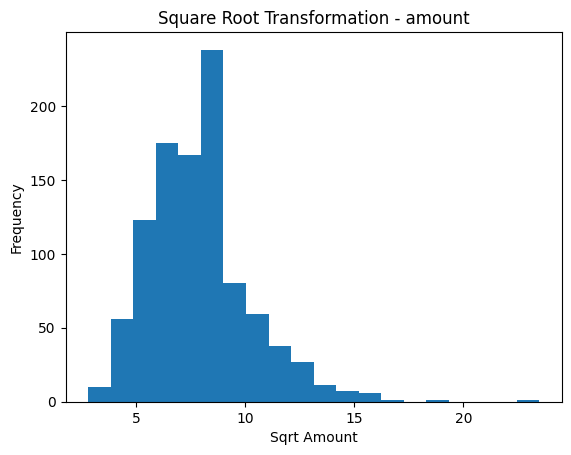

Skewness After Square Root: 1.102881532683231


In [326]:
print("Skewness Before Square Root:", df_sales_csv['amount'].skew())

plt.figure()
plt.hist(df_sales_csv['amount'], bins=20)
plt.title("Before Square Root Transformation - amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

df_sales_csv['amount_sqrt'] = np.sqrt(df_sales_csv['amount'])

plt.figure()
plt.hist(df_sales_csv['amount_sqrt'], bins=20)
plt.title("Square Root Transformation - amount")
plt.xlabel("Sqrt Amount")
plt.ylabel("Frequency")
plt.show()

print("Skewness After Square Root:", df_sales_csv['amount_sqrt'].skew())

After applying square root transformation every value for replaced by its root value. Maximum frequency of values were between 25 - 64 before square root transformation and after appying square root transformation the Maximum frequency of values were reduced and replaced by 5 - 8.

5. Feature Scaling:   

**Using StandardScaler in json file and amount column**


In [327]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
users_scaled = pd.DataFrame(
    scaler_std.fit_transform(df_sales_csv[['amount']]),
)

print("Original:\n")
print(df_sales_csv['amount'].describe())

print("\nScaled:\n")
print(users_scaled.describe())

Original:

count    1000.000000
mean       67.368133
std        43.526265
min         7.810000
25%        39.192500
50%        61.150000
75%        79.355000
max       550.950000
Name: amount, dtype: float64

Scaled:

                  0
count  1.000000e+03
mean   2.309264e-17
std    1.000500e+00
min   -1.369011e+00
25%   -6.476488e-01
50%   -1.429308e-01
75%    2.755317e-01
max    1.111568e+01


After applying StandardScaler, the mean value was nearly equal to 0 and standard deviation was equal to 1.  
  orginal: mean- 67.599040, std- 45.411375, min- 7.810000, max- 550.950000  
std scaled: mean -3.730349e-17, std- 1.000500e+00, min -1.317268e+00, max- 1.064916e+01

**Using MinMaxScaler in json file in amount column**

In [328]:
scaler_mm = MinMaxScaler()
sales_scaled = pd.DataFrame(
    scaler_mm.fit_transform(df_sales_csv[['amount']]),
    columns=df_sales_csv[['amount']].columns
)

print("Original:")
print(df_sales_csv['amount'].describe(),'\n')
print(pd.DataFrame({'amount': df_sales_csv['amount'], 'amount_scaled': sales_scaled['amount']}).head())
print("\n\nScaled:")
print(sales_scaled.describe())

Original:
count    1000.000000
mean       67.368133
std        43.526265
min         7.810000
25%        39.192500
50%        61.150000
75%        79.355000
max       550.950000
Name: amount, dtype: float64 

   amount  amount_scaled
0   67.67       0.110211
1   76.44       0.126358
2  104.57       0.178149
3  102.75       0.174798
4   23.89       0.029606


Scaled:
            amount
count  1000.000000
mean      0.109655
std       0.080138
min       0.000000
25%       0.057780
50%       0.098207
75%       0.131725
max       1.000000


After applying minmax scaler the value of each row inside the amount column will be in the range of 0 to 1.  
Original: mean- 67.599040, std- 45.411375, min- 7.810000, max- 550.950000  
Minmax scaled: mean- 0.110080, std- 0.083609, min- 0.000000, max- 1.000000

6. Feature Construction  
**Average monthly spend per customer.**

In [329]:
df_sales_csv['amount_avg']=df_sales_csv['amount'] / 12
df_sales_csv.head()

,transaction_id,user_id,product_id,amount,payment_type,date,amount_log,amount_sqrt,amount_avg
0,T000001,U0024,P015,67.67,Wallet,2023-02-12,4.214643,8.226178,5.639167
1,T000002,U0196,P044,76.44,UPI,2023-03-24,4.336506,8.742997,6.370000
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21,4.649857,10.225947,8.714167
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23,4.632299,10.136567,8.562500
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04,3.173460,4.887740,1.990833


**Frequency of purchase by payment type**

Total Amount by Payment Type:

  payment_type        amount
0         Cash   9424.543867
1  Credit Card   8642.281333
2   Debit Card  10195.232000
3  Net Banking  10963.798933
4          UPI  10101.503867
5       Wallet  10580.230133


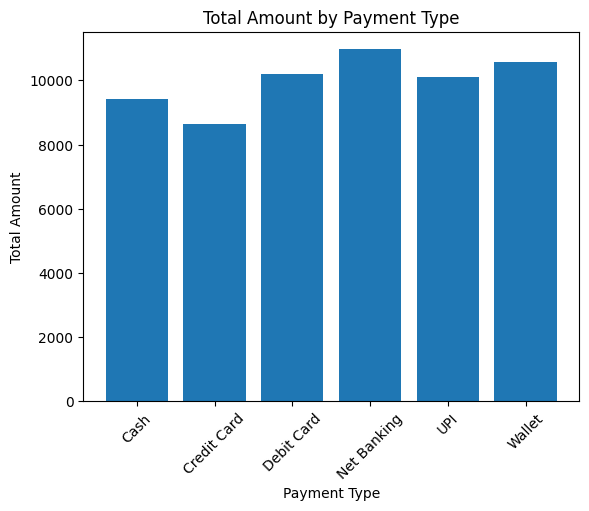

In [330]:
payment_summary = df_sales_csv.groupby("payment_type")["amount"].sum().reset_index()

print("Total Amount by Payment Type:\n")
print(payment_summary)

plt.figure()
plt.bar(payment_summary["payment_type"], payment_summary["amount"])
plt.title("Total Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

The highest payment was done by Net Banking - 10963.798933.  
The lowest payment was done by Credit Card - 8642.281333.

**Days since last purchase**

In [331]:
df_sales_csv['day_of_year'] = df_sales_csv['date'].dt.dayofyear
df_sales_csv['number_of_days'] = (pd.Timestamp('2026-02-22') - df_sales_csv['date']).dt.days
print(df_sales_csv[['date', 'number_of_days']].head(10))

        date  number_of_days
0 2023-02-12            1106
1 2023-03-24            1066
2 2025-08-21             185
3 2024-07-23             579
4 2025-10-04             141
5 2025-04-16             312
6 2023-08-03             934
7 2025-10-11             134
8 2023-03-17            1073
9 2024-05-31             632


**Calculating average age of gender**  

In [332]:
gender_stats = df.groupby('new_gender').size().mean
gender_stats

<bound method Series.mean of new_gender
Female    55
Male      69
Other     56
dtype: int64>

8. Bonus  
**Pandas Profiling**

In [333]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title='Users Dataset EDA Report', explorative=True)
# output_path = 'D:/data preprocessing/practical/users_eda_report.html'
# profile.to_file(output_path)

# print("EDA report generated successfully.")

**Saving cleaned dataset**

In [335]:
final_cleaned_dataset=df
final_cleaned_dataset.to_csv('final_cleaned_dataset.csv')
final_cleaned_dataset

,user_id,name,age,gender,registration_date,new_gender,day,month,year,city_Ahmedabad,...,city_Kolkata,city_Lucknow,city_Mumbai,city_Nagpur,city_Patna,city_Pune,city_Surat,city_Thane,city_Vadodara,city_Visakhapatnam
0,U0001,Vihaan Sharma,"(32.0, 39.0]",2,2022-09-08,Other,Thursday,September,2022,False,...,False,False,False,False,False,False,False,False,False,False
1,U0002,Sai Reddy,"(25.0, 32.0]",2,2023-11-24,Other,Friday,November,2023,False,...,False,False,False,False,False,False,False,False,False,False
2,U0003,Aarohi Gupta,"(32.0, 39.0]",2,2022-02-02,Other,Wednesday,February,2022,False,...,True,False,False,False,False,False,False,False,False,False
3,U0004,Aarav Gupta,"(39.0, 46.0]",1,2023-06-02,Male,Friday,June,2023,False,...,True,False,False,False,False,False,False,False,False,False
4,U0005,Sara Sharma,"(25.0, 32.0]",3,2024-01-04,NaN,Thursday,January,2024,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,U0196,Kabir Kulkarni,"(32.0, 39.0]",2,2024-08-01,Other,Thursday,August,2024,False,...,False,False,False,False,True,False,False,False,False,False
196,U0197,Kabir Roy,"(17.965, 25.0]",1,2023-12-07,Male,Thursday,December,2023,False,...,False,False,False,False,False,False,False,True,False,False
197,U0198,Kabir Bose,"(32.0, 39.0]",0,2023-07-07,Female,Friday,July,2023,False,...,True,False,False,False,False,False,False,False,False,False
198,U0199,Meera Roy,"(25.0, 32.0]",1,2022-02-10,Male,Thursday,February,2022,False,...,False,False,False,False,False,False,False,False,False,False
